<a href="https://colab.research.google.com/github/reezyhudson865/AI_Projects/blob/main/HuggingFace_GenAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI 301 - Challenge Lab 01: Introduction to Generative AI with Hugging Face

**Course:** AI 301 - Natural Language Processing and Conversational AI
**Notebook:** Challenge Lab 01, your first hands on contact with generative models
**Student:** Reezy Hudson   **Date:** Aug 24 2026

In this assignment you will:

- Run three kinds of pretrained model: text, translation, speech
- Image generation is included as optional extra credit
- Change their settings and write down what you see
- Not train anything. The models are ready made.

How the notebook works:

- Each section first defines a function, then calls it in the next cell
- New Python ideas are explained in notes marked **Python note**. These are there because AI 301 does not assume everyone arrives with the same Python background. If a note covers something you already know, skip it. If it is new, read it before running the cell below it.
- If a cell fails, post the error in Course Q&A on Canvas

---

*Some materials adapted from the NVIDIA and Dartmouth Generative AI Teaching Kit (CC BY-NC 4.0). Documentation: [huggingface.co/docs](https://huggingface.co/docs).*

In [ ]:
!pip install -q transformers diffusers gTTS accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 52.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spacy 3.8.15 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.


In [ ]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import MarianMTModel, MarianTokenizer
from diffusers import StableDiffusionPipeline
from IPython.display import Audio, display

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

if device == "cpu":
    print("WARNING: no GPU detected. Runtime > Change runtime type > GPU.")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


In [ ]:
model_name = "gpt2-medium"

gpt2_model = GPT2LMHeadModel.from_pretrained(model_name).to(device)
gpt2_tokenizer = GPT2Tokenizer.from_pretrained(model_name)

print("Without return_tensors, plain lists:")
print(gpt2_tokenizer("Hello world"))
print()
print("With return_tensors='pt', tensors:")
print(gpt2_tokenizer("Hello world", return_tensors="pt").to(device))

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Without return_tensors, plain lists:
{'input_ids': [15496, 995], 'attention_mask': [1, 1]}

With return_tensors='pt', tensors:
{'input_ids': tensor([[15496,   995]], device='cuda:0'), 'attention_mask': tensor([[1, 1]], device='cuda:0')}


In [ ]:
def generate_text(prompt, max_length=50, num_return_sequences=1, temperature=0.8):
    # Encode the prompt
    inputs = gpt2_tokenizer(prompt, return_tensors="pt").to(device)

    outputs = gpt2_model.generate(
        inputs["input_ids"],
        max_length=max_length,
        num_return_sequences=num_return_sequences,
        do_sample=True,
        temperature=temperature
    )

    # Decode every returned sequence back into readable text.
    results = []
    for output in outputs:
        results.append(gpt2_tokenizer.decode(output, skip_special_tokens=True))
    return results

### Calling it

In [ ]:
prompt = "Once upon a time in a land far, far away"
generated = generate_text(prompt)

print("Prompt:")
print(prompt)
print()
print("Generated continuation:")
print(generated[0])

Prompt:
Once upon a time in a land far, far away

Generated continuation:
Once upon a time in a land far, far away...

Then they came to me,

And said, "Come, let us make our bed together."

So I took them both up in a dream,

And


In [ ]:
creative_prompt = "The black cat ran up the marble stairs of the palace."

stories = generate_text(creative_prompt, max_length=100, num_return_sequences=3)

for i, story in enumerate(stories):
    print(f"--- Continuation {i + 1} ---")
    print(story)
    print()

#different temperature and compare.
stories_cold = generate_text(creative_prompt, max_length=100, num_return_sequences=3, temperature=0.3)
stories_hot  = generate_text(creative_prompt, max_length=100, num_return_sequences=3, temperature=1.2)

--- Continuation 1 ---
The black cat ran up the marble stairs of the palace. It walked around the room like a cat. It looked at the white curtains, and looked at the black cat, and then at the maidservant, and then at the maidservant who was holding her dog. It had been a long time for the black cat to make its move. It walked along the marble staircase until it reached the black cat, who was standing by the window.

[Liu Xin, come back

--- Continuation 2 ---
The black cat ran up the marble stairs of the palace. It was now early morning. He climbed to the roof of the palace and looked out over the city. He could see the dark sky above and saw the clouds. He started walking down the steps, but the black cat ran after him. The black cat ran so far that he reached the upper floor, and they took opposite directions along the steps until the black cat passed through the palace.

Kong:

We have a

--- Continuation 3 ---
The black cat ran up the marble stairs of the palace. To him, the room 


The first iteration introduced other animals and an introspective plot theme, but stayed around an animal theme. The second iteration, the "cold story", was extremeley unsophisticated with simple language that followed the same descriptive pattern of "color-animal" and repeated the word "cat" SEVERAL times. The third iteration, the "hot story" went completely out the box and introduced a sophisticated plot point of murder and a brand new character name that was not inputted by me. I deduce that the higher the temperature setting, the more creativity AI will input.

**Translation**


In [ ]:
marian_cache = {}


def load_translator(src_lang, tgt_lang):
    model_name = f"Helsinki-NLP/opus-mt-{src_lang}-{tgt_lang}"
    if model_name not in marian_cache:
        model = MarianMTModel.from_pretrained(model_name).to(device)
        tokenizer = MarianTokenizer.from_pretrained(model_name)
        marian_cache[model_name] = (model, tokenizer)
    return marian_cache[model_name]


def translate_text(text, src_lang="en", tgt_lang="fr"):
    model, tokenizer = load_translator(src_lang, tgt_lang)

    inputs = tokenizer(text, return_tensors="pt", padding=True).to(device)
    translated = model.generate(**inputs)

    return tokenizer.decode(translated[0], skip_special_tokens=True)

In [ ]:
text_to_translate = "Hello, how are you?"
translated_text = translate_text(text_to_translate)

print("Original text:")
print(text_to_translate)
print()
print("Translated text (English to French):")
print(translated_text)

config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

...

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Original text:
Hello, how are you?

Translated text (English to French):
Bonjour, comment allez-vous ?


In [ ]:
original_sentence = "You are barking up the wrong tree"
languages = ["fr", "de", "es"]

for lang in languages:
    translated = translate_text(original_sentence, "en", lang)
    back_translated = translate_text(translated, lang, "en")
    print(f"{lang.upper()}: {translated}")
    print(f"Back to English: {back_translated}")
    print()

config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.59M [00:00<?, ?B/s]

ES: Estás ladrando el árbol equivocado.
Back to English: You're barking the wrong tree.





The word "up" was lost from 2 of the 3 round trips. I think we had a tendency to lose that word because it is not exactly integral to the meaning of the idiom. The lack of the word "up" makes the phrase lose a hint of meaning at the phrase describes the act up chatting up to someone who holds a position of authority in the correspondence. Although, I would argue that most people could still acquire the meaning of the idiom without the word "up".

---

## 4. Audio


In [ ]:
!pip install -q openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 28.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


### Text to speech

gTTS produces MP3 data, so the file is named `.mp3`.

In [ ]:
from gtts import gTTS
from IPython.display import Audio

#Example text to synthesize
text = "This is an example of text to speech in Google Colab."

tts = gTTS(text)

tts.save("output.mp3")

Audio("output.mp3", autoplay=False)

### Transcription


In [ ]:
import whisper

#Load the model once and reuse it.
whisper_model = whisper.load_model("base")


def transcribe_audio(file_path):
    result = whisper_model.transcribe(file_path)
    return result["text"]

100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 241MiB/s]


### Calling it

In [ ]:
transcribed_text = transcribe_audio("output.mp3")

print("Original text:")
print(text)
print()
print("Transcribed text:")
print(transcribed_text)

Original text:
This is an example of text to speech in Google Colab.

Transcribed text:
 This is an example of text to speech in Google Colab.


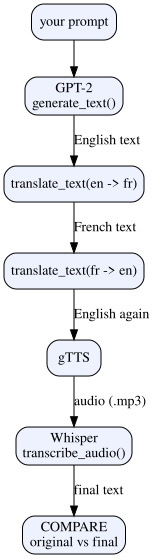

In [ ]:
from graphviz import Digraph

pipeline = Digraph()
pipeline.attr(rankdir="TB")   #TB = top to bottom
pipeline.attr("node", shape="box", style="rounded,filled", fillcolor="#eef2ff")

# Each line is one arrow: edge(from_box, to_box, label_on_the_arrow)
pipeline.edge("your prompt", "GPT-2\ngenerate_text()")
pipeline.edge("GPT-2\ngenerate_text()", "translate_text(en -> fr)", label="English text")
pipeline.edge("translate_text(en -> fr)", "translate_text(fr -> en)", label="French text")
pipeline.edge("translate_text(fr -> en)", "gTTS", label="English again")
pipeline.edge("gTTS", "Whisper\ntranscribe_audio()", label="audio (.mp3)")
pipeline.edge("Whisper\ntranscribe_audio()", "COMPARE\noriginal vs final", label="final text")

pipeline   # the last line of a cell is what gets displayed

In [ ]:
#generate a passage of text with GPT-2
chain_text = generate_text("The history of the printing press begins", max_length=60)[0]
print("GPT-2 text:", chain_text)

#translate it to French
french = translate_text(chain_text, src_lang ="en", tgt_lang="fr")

#translate the French back to English
back_to_english = translate_text(french, src_lang="fr", tgt_lang="en")

#convert back_to_english to speech, save it as "chain_audio.mp3", and play it
tts = gTTS(back_to_english)
tts.save("chain_audio.mp3")
Audio("chain_audio.mp3", autoplay=False)

#transcribe "chain_audio.mp3" back to text
transcribed_text = transcribe_audio("chain_audio.mp3")

#print chain_text and the final transcription side by side
print("Chain text:")
print(chain_text)
print()
print("Transcribed text:")
print(transcribed_text)

GPT-2 text: The history of the printing press begins with two brothers, who came to Boston from the French colonies. Joseph and Thomas Bell, who would become known as the "printing press boys," soon discovered that the machines made of metal and paper could be used to make books. Since the paper was a scarce
Chain text:
The history of the printing press begins with two brothers, who came to Boston from the French colonies. Joseph and Thomas Bell, who would become known as the "printing press boys," soon discovered that the machines made of metal and paper could be used to make books. Since the paper was a scarce

Transcribed text:
 The history of printing begins with two brothers, who came to Boston from the French colonies, Joseph and Thomas Bell, who would be known as the printing wires, quickly discovered that metal and paper machines could be used to make books.


**Question 1.** What was the most surprising or interesting result you got in this notebook, and why?

I was suprised as to the overall efficiency of the code. This shocked me because many speech to text transcriptions that are available on things like Youtube videos are often very poor. I wonder how their automated captions programming differs in a way that makes it less effective.

**Question 2.** Modern chatbots (ChatGPT, Claude, Gemini) also work by predicting the next token. Based on your GPT-2 outputs, name two things they do that GPT-2 could not, and suggest what makes the difference.

GPT-2 mainly produced outputs that were continuations of pre-trained patterns that may not have necessarily taken context from current interactions, vs ChatGPT could filter in context from user inputs to form more tailored responses.
GPT-2 also could not reason through multi step problems or with greater nuance like ChatGPT can.
The difference between GPT-2 and ChatGPT in both of these scenarios is the evolution of training overtime due to an increased abundance of data from previous feedback engines that allowed programmers to implement more systems to greater meet users' needs.

**Question 3.** The tokenizer turned "Hello world" into `[15496, 995]` before the model saw it. Why do models need numbers instead of words? What would go wrong with one number per whole English word?

Models needs numbers in order to form proper sequences of mathematical functions, which is how Language Models work. One number per whole English word could result in extremely slow computing and immense impracticality because there are so many words in the English language that have multiple forms, as well as new words like slang that infiltrate common speech every year. It is just not entirely possible for a tokenizer to acquire every single word.

**Question 4.** Explain the temperature tradeoff using your Exercise 1 outputs. Name one application where you would set it low and one where you would set it high.

The temperature tradeoff is a preference to determine how simplisitc and predictable a word output would generate speech. If I wanted to use a Generative AI to create a story for children, I would set a low temperature in order to prevent large words and lofty plot points, versus if I wanted an AI to write a scholarly research article, I would use a high temperature to ensure it sounded intellectual.

**Question 5.** Somewhere in your Exercise 1 outputs, GPT-2 probably wrote something fluent but false or invented. Why does a model that predicts the next token produce confident nonsense? What would it take for a model to know whether what it writes is true? Hint: OpenAI's short read [Why language models hallucinate](https://openai.com/index/why-language-models-hallucinate/) is a good starting point.

Models that predict the next token might produce confident nonsense due to the nature of being made to fulfill the request at hand, regardless of lack of information. Most models are programmed to produce an output regardless of actual access to the correct answer, so in order to fulfill a command, they tend to supplement with totally false information. A fix for a model to know whether what it writes is true is to make more efforts to train and reward models to admit lack of knowledge rather than constantly encourage a responses by all means necessary.

**Question 6.** Exercise 3 chained several models. In a chain of ten models, what new problem appears, and how would you find which stage was causing an error?

Longer chain models can cause errors in earlier chains to get repeatedly compounded, making the error gradually grow in severity. In order to locate the error stage, you would need to run the output after each chain and identify which stage has an output that does not match its input.

**Question 7.** `temperature` is not the only setting that shapes generation. Pick one of `top_k`, `top_p`, or `repetition_penalty` from the [Hugging Face generation settings](https://huggingface.co/docs/transformers/main_classes/text_generation), explain what it does, and say what you would expect to change in your Exercise 1 outputs if you added it to the `generate_text` call. Try it if you are curious. Write it in your own words.

top_k ranks tokens of the highest probability and prompts the model to choose amoung the top range you input. If I used it instead of temperature, lower top_k values would produce more predictable stories with less word variety, kind of like low temperature.

**Question 8.** Pick one of the four capabilities. Search for a real news article about harm caused by careless deployment of that capability. Link the article, summarize it in two or three sentences, say who was affected, and name one thing the deployer could have done to reduce the harm.

Using Generative AI for image generation can cause serious harm. One example of this, written about by AP News is the rise of "deepfakes", AI generated images of people, often showcasing them in explicit and compromising situations. The article by AP News follows how X users used the in app AI feature Grok to generate explicit images of singer Taylor Swift, which sparked public outcry of her fanbase and women all across the internet. The case of Taylor Swift has been referenced in calls to action by U.S. Representatives to introduce legal parameters of the ability of these agents to create such images, as well as charges against the people who make or distribute them. Other AI services like OpenAI report that they have safeguards in place that decline any requests of individuals by name. X and Grok could reduce such harm by implementing the same standards, however their CEO continues to challenge such rhetoric over a concern of the case of free speech.

Article link: https://apnews.com/article/taylor-swift-ai-images-protecttaylorswift-nonconsensual-d5eb3f98084bcbb670a185f7aeec78b1